<a href="https://colab.research.google.com/github/aiaaee/Forward-Kinematics-Prediction-of-KUKA-LBR-iiwa/blob/main/ForwardKinematic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robot Kinematic Dataset


## Downloads

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


## Imports

In [2]:
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor , Pool
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import RobustScaler , PowerTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score , mean_absolute_error

In [4]:
path = '/content/IKRobot (1).csv'
data = pd.read_csv(path)

In [5]:
data.head(5)

,Unnamed: 0,q1,q2,q3,q4,q5,q6,q7,X,Y,Z
0,0,-2.205594,1.150757,0.687245,0.617608,-1.508887,0.455022,1.520704,-0.570587,-0.415378,0.868396
1,1,-1.124737,1.872321,-0.733617,-0.590998,-0.681451,1.688314,-1.178301,0.054546,-0.658910,-0.006440
2,2,0.674333,-0.988896,1.636789,2.046064,2.811623,-1.598001,1.901635,0.060319,-0.456072,0.586749
3,3,0.875620,1.074150,-0.701521,-0.638272,-0.392089,2.081719,-2.061057,0.580772,0.379792,0.506077
4,4,2.486889,0.160019,0.944657,-1.725151,1.947199,-1.719547,1.124840,-0.423750,0.011046,0.633388


In [6]:
df = data.copy()

## Explority Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  10000 non-null  int64  
 1   q1          10000 non-null  float64
 2   q2          10000 non-null  float64
 3   q3          10000 non-null  float64
 4   q4          10000 non-null  float64
 5   q5          10000 non-null  float64
 6   q6          10000 non-null  float64
 7   q7          10000 non-null  float64
 8   X           10000 non-null  float64
 9   Y           10000 non-null  float64
 10  Z           10000 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 859.5 KB


In [8]:
df.drop(['Unnamed: 0'] , inplace=True , axis=1)

In [9]:
df.describe()

,q1,q2,q3,q4,q5,q6,q7,X,Y,Z
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.044589,-0.002992,0.007384,0.001173,-0.002427,-0.002066,0.002622,0.003178,0.000217,0.607523
std,1.702419,1.210642,1.725577,1.210059,1.710775,1.213093,1.754405,0.402858,0.416563,0.368140
min,-2.965580,-2.094368,-2.966272,-2.094242,-2.966469,-2.094285,-3.054297,-0.891057,-0.905137,-0.324474
25%,-1.411341,-1.046868,-1.498321,-1.047187,-1.503457,-1.064488,-1.512942,-0.319883,-0.335315,0.332265
50%,0.078461,-0.009012,0.029461,-0.015034,-0.017316,-0.002330,-0.006580,0.003398,-0.001575,0.648335
75%,1.521692,1.054956,1.476093,1.045217,1.486997,1.048199,1.500535,0.323522,0.333214,0.903025
max,2.966530,2.094324,2.965949,2.094351,2.966195,2.094302,3.054174,0.917529,0.903546,1.280526


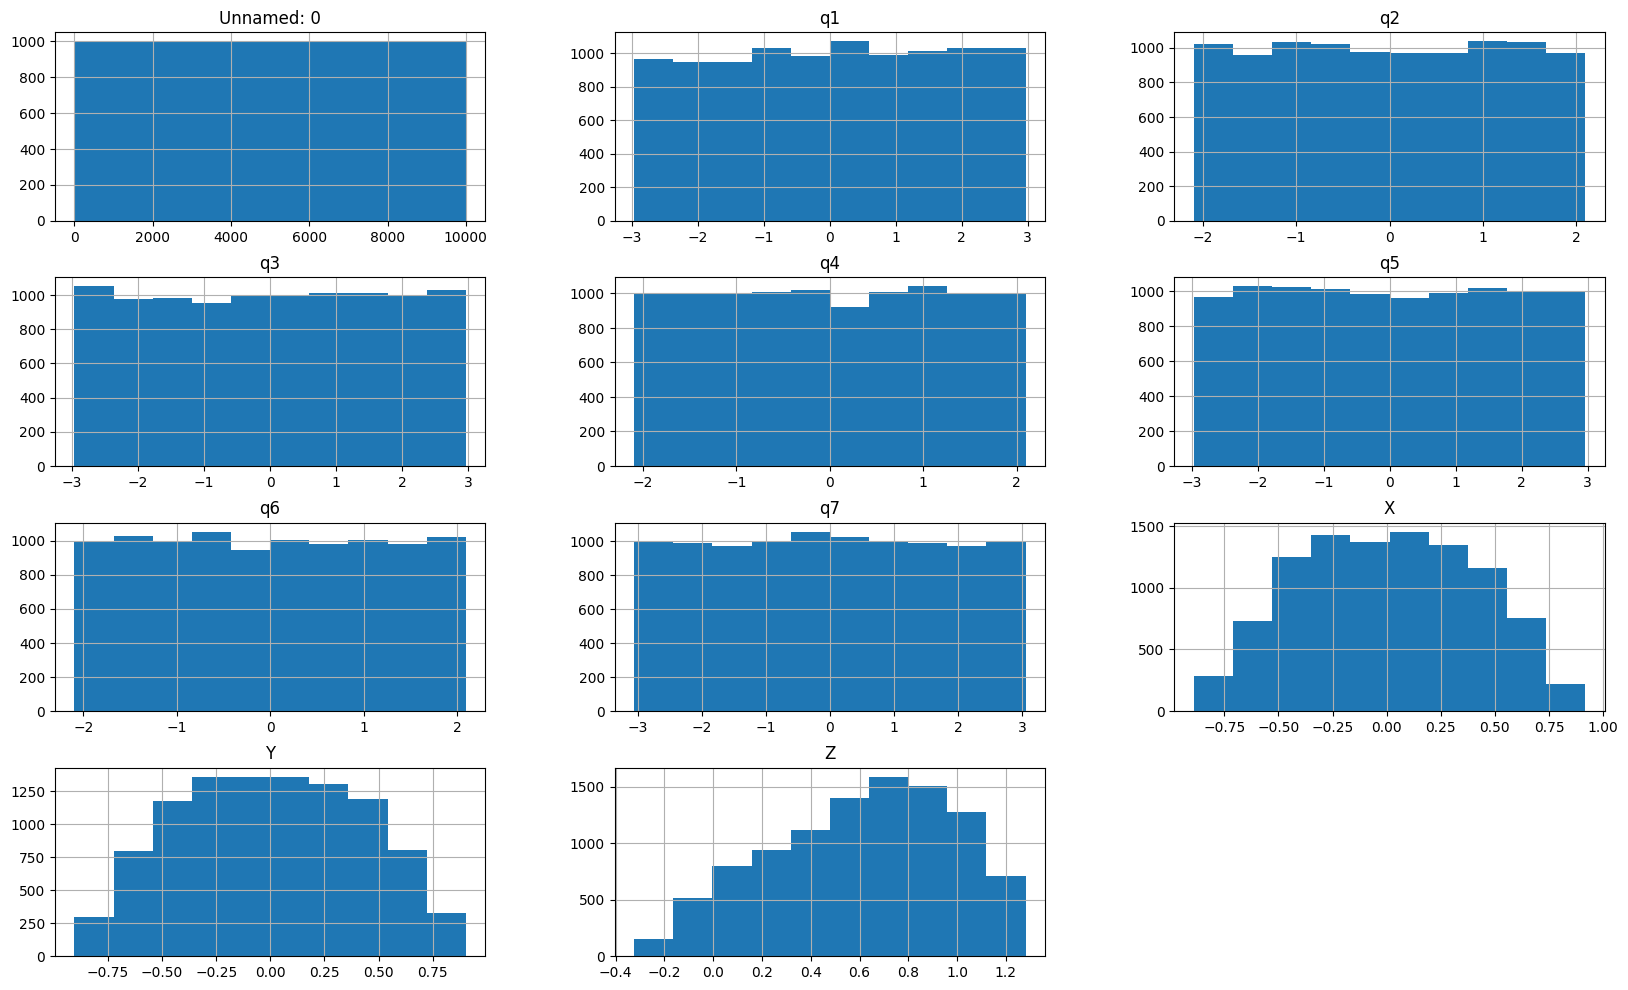

In [10]:
data.hist(figsize=(20, 12));

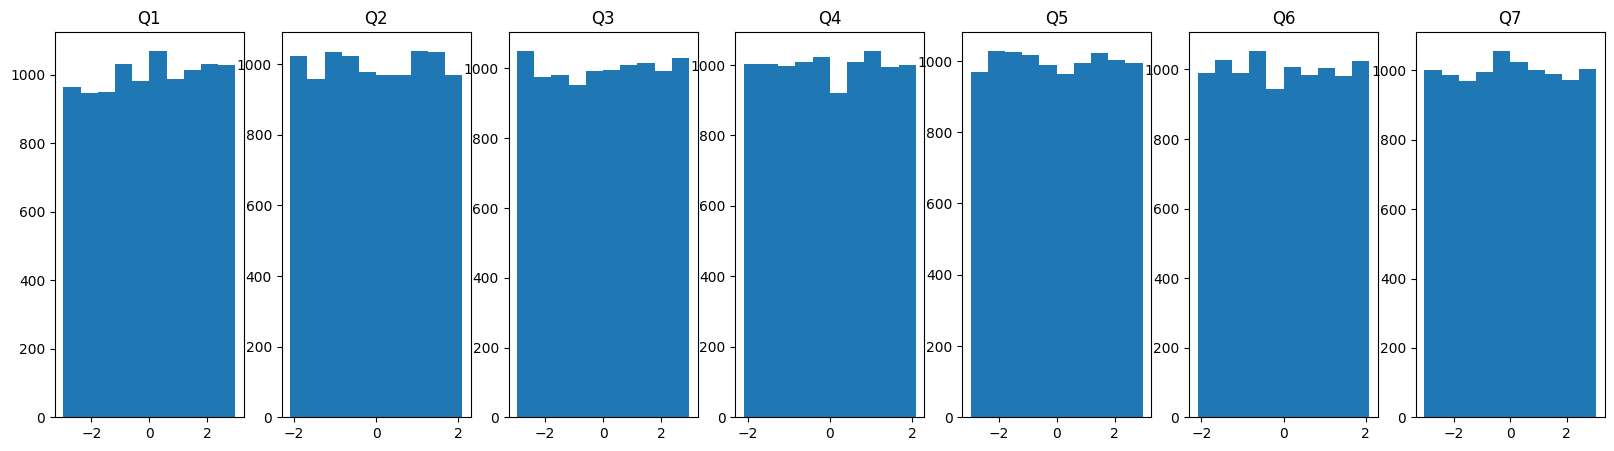

In [11]:
fig , axes = plt.subplots(ncols=7 , figsize=(20 , 5))

axes[0].hist(df['q1'])
axes[1].hist(df['q2'])
axes[2].hist(df['q3'])
axes[3].hist(df['q4'])
axes[4].hist(df['q5'])
axes[5].hist(df['q6'])
axes[6].hist(df['q7'])





axes[0].set(title='Q1')
axes[1].set(title='Q2')
axes[2].set(title='Q3')
axes[3].set(title='Q4')
axes[4].set(title='Q5')
axes[5].set(title='Q6')
axes[6].set(title='Q7')

plt.show()

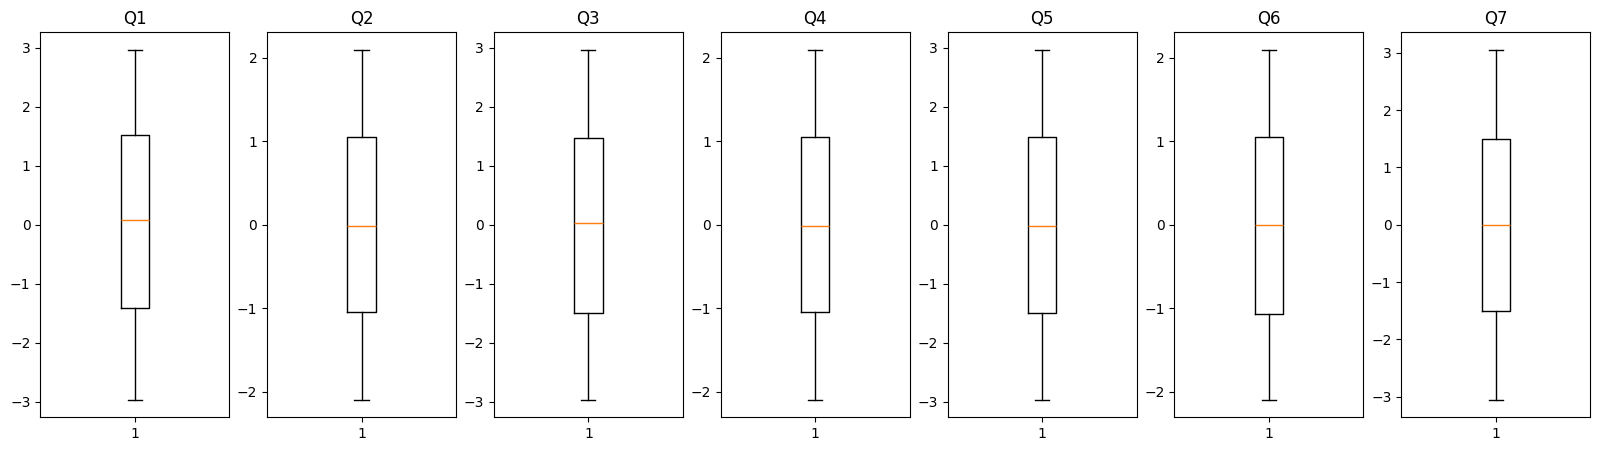

In [12]:
fig, ax = plt.subplots(ncols=7 , figsize=(20 , 5 ))
ax[0].boxplot(df['q1'])
ax[1].boxplot(df['q2'])
ax[2].boxplot(df['q3'])
ax[3].boxplot(df['q4'])
ax[4].boxplot(df['q5'])
ax[5].boxplot(df['q6'])
ax[6].boxplot(df['q7'])


ax[0].set(title='Q1')
ax[1].set(title='Q2')
ax[2].set(title='Q3')
ax[3].set(title='Q4')
ax[4].set(title='Q5')
ax[5].set(title='Q6')
ax[6].set(title='Q7')

plt.show()

<Axes: ylabel='Density'>

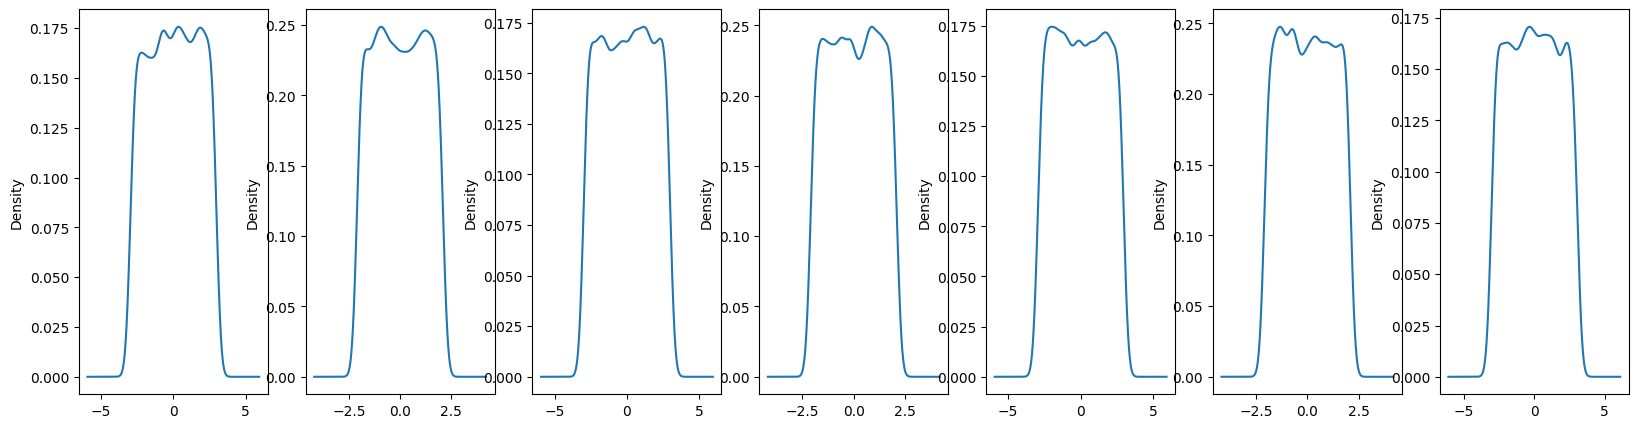

In [13]:
fig , axes = plt.subplots(ncols=7 , figsize=(20, 5 ))

df['q1'].plot(kind='kde', ax=axes[0])
df['q2'].plot(kind='kde', ax=axes[1])
df['q3'].plot(kind='kde' , ax=axes[2])
df['q4'].plot(kind='kde' , ax=axes[3])
df['q5'].plot(kind='kde' , ax=axes[4])
df['q6'].plot(kind='kde' , ax=axes[5])
df['q7'].plot(kind='kde' , ax=axes[6])

<Axes: ylabel='Density'>

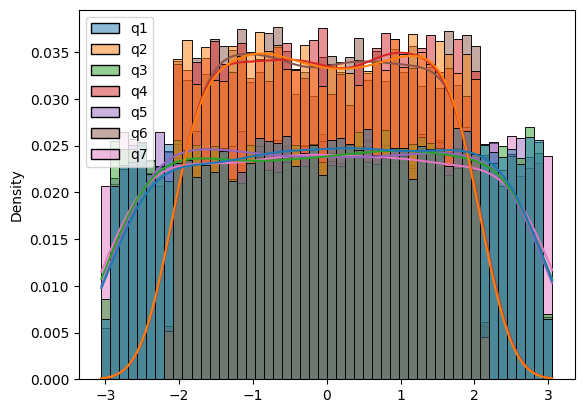

In [14]:
sns.histplot(df[['q1' , 'q2' , 'q3' , 'q4' , 'q5' , 'q6' , 'q7']], kde=True, stat="density", kde_kws={'bw_adjust': 1.8})

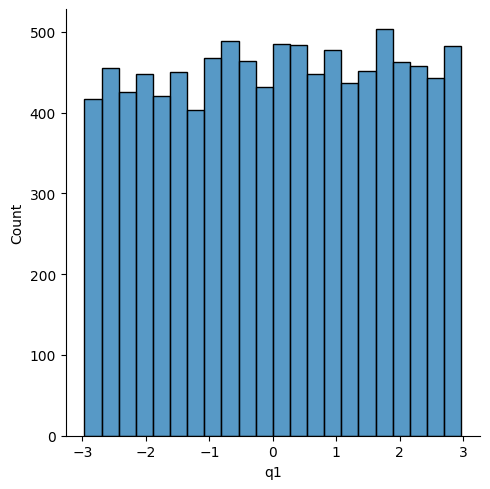

In [15]:
sns.displot(data=df, x='q1');

In [16]:
df.corr()

,q1,q2,q3,q4,q5,q6,q7,X,Y,Z
q1,1.000000,-0.004917,-0.001463,0.007821,0.004300,-0.001026,-0.004769,0.009550,-0.010203,-0.000909
q2,-0.004917,1.000000,0.012342,-0.011391,0.014689,0.014456,-0.007424,0.073645,0.018069,-0.003704
q3,-0.001463,0.012342,1.000000,-0.001871,-0.005773,-0.011340,-0.007902,0.007622,0.000401,-0.027479
q4,0.007821,-0.011391,-0.001871,1.000000,0.008979,-0.005417,0.012409,0.006330,-0.008657,0.002283
q5,0.004300,0.014689,-0.005773,0.008979,1.000000,-0.002277,0.004163,-0.014726,0.007903,0.013769
q6,-0.001026,0.014456,-0.011340,-0.005417,-0.002277,1.000000,0.021543,0.009995,-0.019180,-0.008550
q7,-0.004769,-0.007424,-0.007902,0.012409,0.004163,0.021543,1.000000,-0.005168,0.011928,0.004028
X,0.009550,0.073645,0.007622,0.006330,-0.014726,0.009995,-0.005168,1.000000,-0.003248,-0.001614
Y,-0.010203,0.018069,0.000401,-0.008657,0.007903,-0.019180,0.011928,-0.003248,1.000000,-0.003843
Z,-0.000909,-0.003704,-0.027479,0.002283,0.013769,-0.008550,0.004028,-0.001614,-0.003843,1.000000


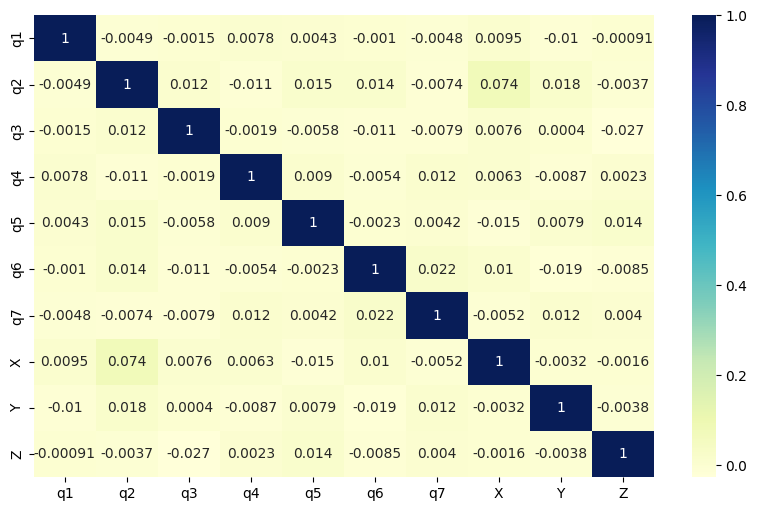

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap="YlGnBu");

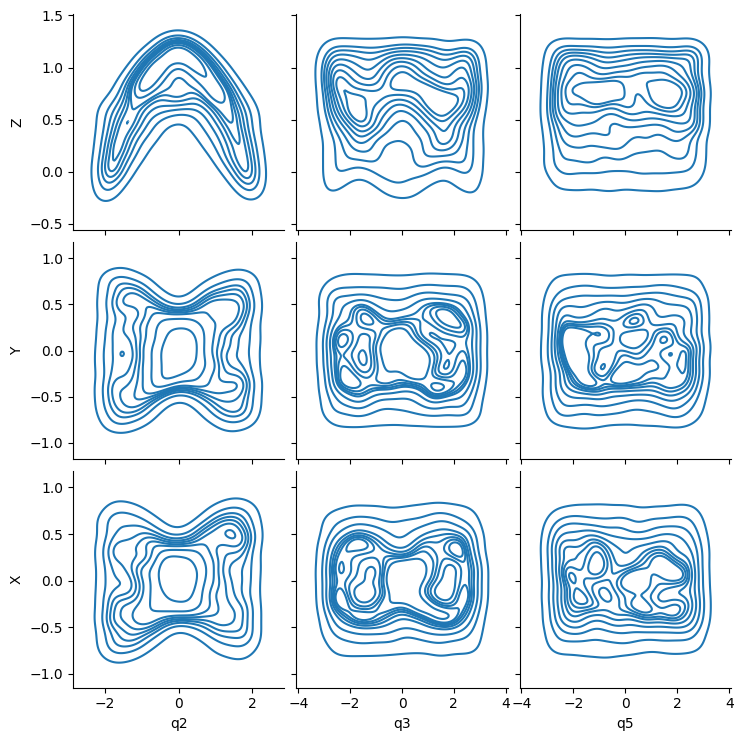

In [18]:
sns.pairplot(df, x_vars=['q2', 'q3', 'q5'],
             y_vars=['Z', 'Y', 'X'],
             kind='kde',)

## Data Processing

In [19]:
X = df.drop(['X', 'Y' , 'Z'] , axis=1)
y = df[['X' , 'Y' , 'Z']]

In [20]:
X

,q1,q2,q3,q4,q5,q6,q7
0,-2.205594,1.150757,0.687245,0.617608,-1.508887,0.455022,1.520704
1,-1.124737,1.872321,-0.733617,-0.590998,-0.681451,1.688314,-1.178301
2,0.674333,-0.988896,1.636789,2.046064,2.811623,-1.598001,1.901635
3,0.875620,1.074150,-0.701521,-0.638272,-0.392089,2.081719,-2.061057
4,2.486889,0.160019,0.944657,-1.725151,1.947199,-1.719547,1.124840
...,...,...,...,...,...,...,...
9995,-2.422245,-0.489804,-2.727371,-0.571698,-0.612383,-2.064653,-1.759500
9996,0.185609,1.531325,2.259258,1.511389,2.159062,-0.820918,-2.015280
9997,-0.012562,-0.172818,-1.416732,-1.978702,2.136787,-1.218036,2.383230
9998,-0.569181,-0.805009,1.337856,-0.223225,0.641605,1.419900,2.739017


In [21]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3)

In [22]:
X_train

,q1,q2,q3,q4,q5,q6,q7
9655,-1.100480,-0.280395,-2.285837,0.983765,-2.956477,-0.519003,2.346767
2549,2.316085,-1.900301,-0.847863,0.957064,-0.281135,1.209568,-0.040494
5110,1.854083,0.910656,2.772312,-1.911510,-2.132487,0.899166,-1.048530
7501,-0.851417,2.009761,2.002216,1.124773,1.495278,-1.119441,-2.574876
9439,2.306220,-0.356182,1.525805,-0.609906,-2.045769,-0.714021,-1.745043
...,...,...,...,...,...,...,...
5396,-0.216477,1.318876,2.595293,1.335375,-0.398095,2.000530,-2.446338
7694,-0.632576,0.874455,-0.420368,-0.064632,-2.497795,-0.010452,1.255777
1152,0.373354,0.812435,2.960119,0.869276,-2.431246,-0.235640,1.009755
9016,-0.564816,-1.607057,2.722047,-0.550868,-1.929502,0.967248,0.559050


In [23]:
X_train.shape

(7000, 7)

### Scaling the data

In [24]:
pipeline = Pipeline([('Robust Scaler' , RobustScaler()) , ("Power Transformer" , PowerTransformer())])

In [25]:
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [26]:
X_train_transformed.shape

(7000, 7)

In [27]:
features = ['q1','q2','q3','q4','q5','q6', 'q7']
X_train_transformed_df = pd.DataFrame(X_train_transformed , columns=features )

In [28]:
features = ['q1','q2','q3','q4','q5','q6']

scaler = RobustScaler()
X_robust = scaler.fit_transform(df[features])

pt = PowerTransformer()
X_transformed = pt.fit_transform(X_robust)

In [29]:
df_transformed = pd.DataFrame(X_transformed , columns=features)

<Axes: ylabel='Density'>

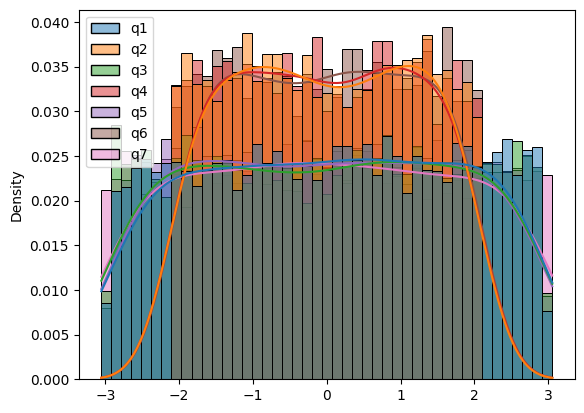

In [30]:
sns.histplot(X_train, kde=True, stat="density", kde_kws={'bw_adjust': 1.8})

<Axes: ylabel='Density'>

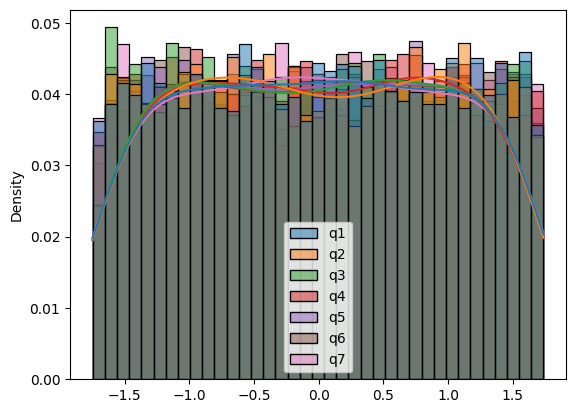

In [31]:
sns.histplot(X_train_transformed_df, kde=True, stat="density", kde_kws={'bw_adjust': 1.8})

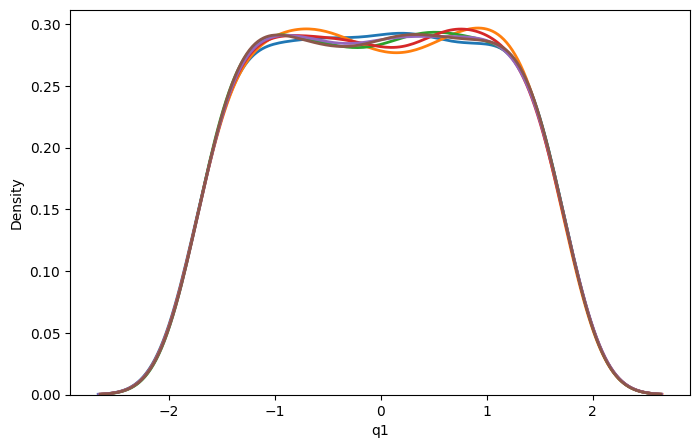

In [32]:
plt.figure(figsize=(8,5))
for col in features:
  sns.kdeplot(X_train_transformed_df[col], bw_adjust=1.8, label=col, linewidth=2)

### Random Forest

In [33]:
rf = RandomForestRegressor()
rf.fit(X_train_transformed , y_train)

RandomForestRegressor()

In [34]:
y_pred = rf.predict(X_test_transformed)

In [35]:
print(f"R2-Score: {r2_score(y_pred , y_test)}")
print(f"Mean Absolute Error : {mean_absolute_error(y_pred , y_test)}")

R2-Score: 0.7875001830853932
Mean Absolute Error : 0.12541786183916268


### XGB Regressor

In [36]:
xgb_reg = XGBRegressor(n_estimators=600,learning_rate=0.05,max_depth=8,n_jobs=-1,random_state=42)

In [37]:
xgb_reg.fit(X_train_transformed , y_train)
xgb_y_pred = xgb_reg.predict(X_test_transformed)

In [38]:
r2_score(xgb_y_pred , y_test)

0.9140362739562988

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

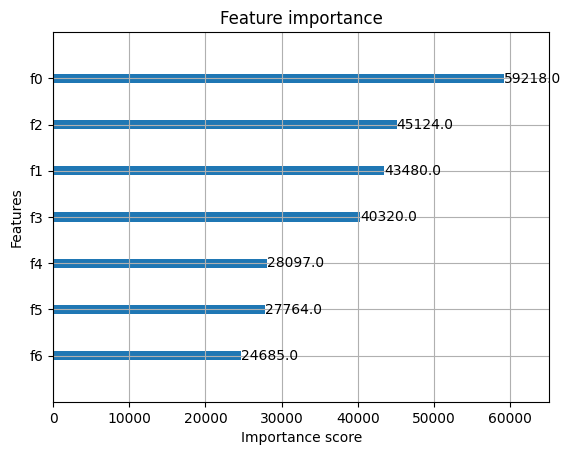

In [39]:
import xgboost as xgb
xgb.plot_importance(xgb_reg)

### Catboost Regressor

In [40]:
train_pool = Pool(X_train , y_train)
test_pool = Pool(X_test , y_test)

In [41]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiRMSE',
    eval_metric='MultiRMSE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

In [42]:
model.fit(train_pool , eval_set=test_pool , use_best_model=True , plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6704802	test: 0.6697174	best: 0.6697174 (0)	total: 56.9ms	remaining: 56.8s
100:	learn: 0.3283826	test: 0.3350169	best: 0.3350169 (100)	total: 739ms	remaining: 6.58s
200:	learn: 0.2510425	test: 0.2619979	best: 0.2619979 (200)	total: 1.42s	remaining: 5.63s
300:	learn: 0.2119425	test: 0.2270183	best: 0.2270183 (300)	total: 2.11s	remaining: 4.9s
400:	learn: 0.1877826	test: 0.2063784	best: 0.2063784 (400)	total: 2.77s	remaining: 4.14s
500:	learn: 0.1713260	test: 0.1934358	best: 0.1934358 (500)	total: 3.48s	remaining: 3.46s
600:	learn: 0.1594627	test: 0.1846563	best: 0.1846563 (600)	total: 4.18s	remaining: 2.78s
700:	learn: 0.1494109	test: 0.1775469	best: 0.1775469 (700)	total: 4.86s	remaining: 2.07s
800:	learn: 0.1403948	test: 0.1708755	best: 0.1708755 (800)	total: 5.58s	remaining: 1.39s
900:	learn: 0.1331636	test: 0.1661314	best: 0.1661240 (897)	total: 6.32s	remaining: 695ms
999:	learn: 0.1268650	test: 0.1620524	best: 0.1620524 (999)	total: 7.05s	remaining: 0us

bestTest = 0.16

CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='MultiRMSE', iterations=1000, learning_rate=0.05, loss_function='MultiRMSE', random_seed=42, verbose=100)

In [43]:
preds = model.predict(X_test)

In [44]:
print(f"R2-Score : {r2_score(y_test , preds)}")
print(f"Mean Absolute Error : {mean_absolute_error(y_test , preds)}")

R2-Score : 0.9457656763473273
Mean Absolute Error : 0.07375718734140878


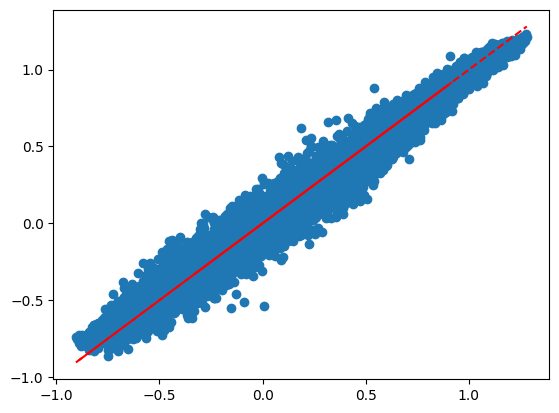

In [45]:
plt.scatter(y_test , preds)
plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')

## Evaluation

In [48]:
position_errors = np.linalg.norm(y_pred - y_test, axis=1)

print("========== Position Error Results ==========")
print(f"Mean Position Error   : {position_errors.mean()*1000:.2f} mm")
print(f"Median Position Error : {np.median(position_errors)*1000:.2f} mm")
print(f"Std Position Error    : {position_errors.std()*1000:.2f} mm")
print(f"Max Position Error    : {position_errors.max()*1000:.2f} mm")
print(f"Min Position Error    : {position_errors.min()*1000:.2f} mm")

print(f"\nSuccess Rate (< 50 mm)  : {(position_errors < 0.05).mean()*100:.1f}%")
print(f"Success Rate (< 100 mm) : {(position_errors < 0.10).mean()*100:.1f}%")
print(f"Success Rate (< 200 mm) : {(position_errors < 0.20).mean()*100:.1f}%")
print(f"Success Rate (< 300 mm) : {(position_errors < 0.30).mean()*100:.1f}%")

========== Position Error Results ==========
Mean Position Error   : 252.68 mm
Median Position Error : 247.22 mm
Std Position Error    : 95.87 mm
Max Position Error    : 628.23 mm
Min Position Error    : 21.12 mm

Success Rate (< 50 mm)  : 0.3%
Success Rate (< 100 mm) : 3.7%
Success Rate (< 200 mm) : 32.3%
Success Rate (< 300 mm) : 69.6%
